In [24]:
from tqdm import trange
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import astropy.units as u
import astropy.coordinates as coord
from astropy.io import fits

from ezpadova import parsec

import gala.coordinates as gc
import gala.dynamics as gd
import gala.potential as gp
from gala.units import galactic
from gala.dynamics import mockstream as ms
_ = coord.galactocentric_frame_defaults.set('v4.0')

## Ibata+21 catalog

[ADS link](https://ui.adsabs.harvard.edu/abs/2021ApJ...914..123I/abstract)

In [25]:
dtype = {
    'names':   ('star_id', 'ra', 'dec', 'plx', 'mu_ra', 'mu_dec', 'G',  'BP-RP', 'd',  'vr', 'evr', 'rvr', 'stream_id'),
    'formats': ('i8',      'f8', 'f8',  'f8',  'f8',    'f8',     'f8', 'f8',    'f8', 'f8', 'f8',  'i8' , 'i8'       )}

d = np.loadtxt('../data/apjabfcc2t1_mrt.txt', dtype=dtype, skiprows=41)

In [26]:
c = coord.ICRS(ra=d['ra'] * u.deg, dec=d['dec'] * u.deg,
    distance=d['d'] * u.kpc,
    pm_ra_cosdec=d['mu_ra'] * u.mas/u.yr,
    pm_dec=d['mu_dec'] * u.mas/u.yr,
    radial_velocity=d['vr'] * u.km/u.s)

c_gal = c.transform_to(coord.Galactic())
l = c_gal.l
b = c_gal.b

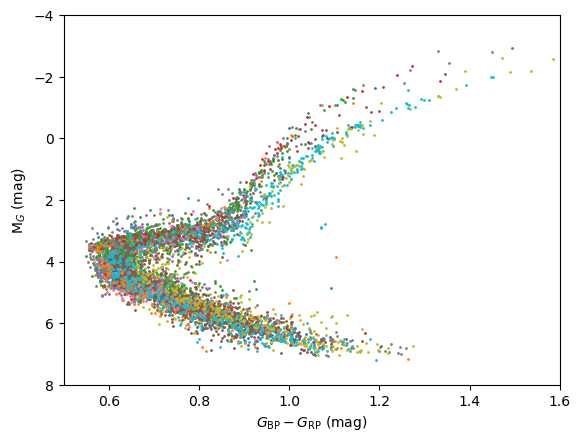

In [27]:
G_abs = d['G'] - 5*(np.log10(d['d'])+2)

for idx in set(d['stream_id']):
    mask = d['stream_id'] == idx
    plt.scatter(d['BP-RP'][mask], G_abs[mask], s=1)

plt.xlabel(r'$G_{\rm BP}-G_{\rm RP}\ ({\rm mag})$')
plt.ylabel(r'${\rm M}_{G}\ ({\rm mag})$')
plt.xlim(0.5,1.6)
plt.ylim(8,-4)
plt.show()

In [5]:
def feh_to_Z(feh):
    return 10.0**(feh)*0.0152

In [20]:
feh_list = np.array([-1.9, -1.5, -1.3, -1.1, -0.7])
Z_list = feh_to_Z(feh_list)

old_iso= [parsec.get_one_isochrone(1.25e10,Z,model='parsec12s_r14',phot='gaia') for Z in Z_list]

Interrogating http://stev.oapd.inaf.it...
Interrogating http://stev.oapd.inaf.it...
Interrogating http://stev.oapd.inaf.it...
Interrogating http://stev.oapd.inaf.it...
Interrogating http://stev.oapd.inaf.it...


In [21]:
def kroupa(mmin, mmax):
    # for 0.5 < mmax < 1 and 0.08 < mmin < 1
    if mmin == 0:
        return -0.676877 * mmax**-0.3 + 1.19048
    if mmin < 0.5:
        return -0.676877 * mmax**-0.3 - 0.580180 * mmin**0.7 + 1.19048
    else:
        return -0.676877 * (mmax**-0.3 - mmin**-0.3)

kroupa = np.vectorize(kroupa)

24928.910766623645


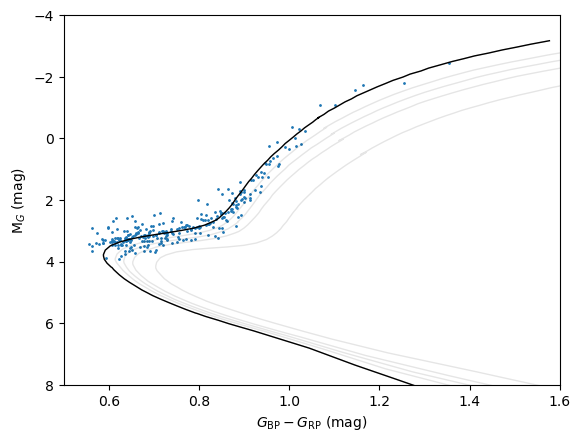

In [28]:
G_limit = 18

# 8: GD-1
# 19: Pal 5

# for idx in set(d['stream_id']):
for idx in [8]:
    mask = (d['stream_id'] == idx) & (d['G']<=G_limit)
    plt.scatter(d['BP-RP'][mask], G_abs[mask], s=1)

# for idx in set(d['stream_id']):
#     mask = d['stream_id'] == idx
#     plt.scatter(d['BP-RP'][mask], G_abs[mask], s=1)
    
comp = np.inf
idx = np.nan

for i in range(len(old_iso)):
    iso = old_iso[i]
    mask1 = iso['label'] <= 3
    color = iso['G_BPmag'][mask1][::-1]-iso['G_RPmag'][mask1][::-1]
    Gmag = iso['Gmag'][mask1][::-1]

    dcolor = d['BP-RP'][mask] - np.interp(G_abs[mask], Gmag, color)
    dcolor = np.mean(dcolor**2)
    if dcolor < comp:
        comp = dcolor
        idx = i
    
    plt.plot(color, Gmag, lw=1, c='k', alpha=0.1)
    
iso = old_iso[idx]
mask1 = iso['label'] <= 3
color = iso['G_BPmag'][mask1][::-1]-iso['G_RPmag'][mask1][::-1]
Gmag = iso['Gmag'][mask1][::-1]
Mini = iso['Mini'][mask1][::-1]
masses = np.interp(G_abs[mask], Gmag, Mini)
plt.plot(color, Gmag, lw=1, c='k', alpha=1)

mass_limit = np.interp(G_limit - 5*(np.log10(d['d'][mask])+2), Gmag, Mini)
weight = kroupa(0, np.max(Mini)) / kroupa(mass_limit, np.max(Mini))
print(np.sum(masses*weight))

plt.xlabel(r'$G_{\rm BP}-G_{\rm RP}\ ({\rm mag})$')
plt.ylabel(r'${\rm M}_{G}\ ({\rm mag})$')
plt.xlim(0.5,1.6)
plt.ylim(8,-4)
plt.show()

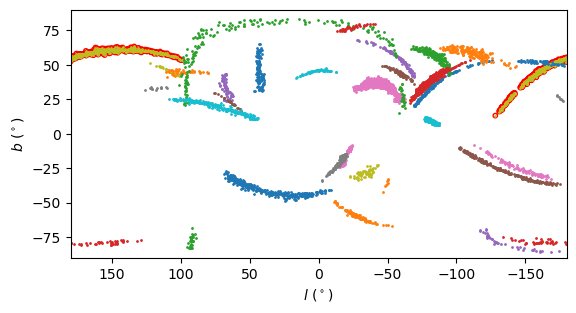

In [31]:


mask = d['stream_id'] == 8
plt.scatter(l[mask].wrap_at(180*u.deg), b[mask], s=10, fc='none', ec='r')

for idx in range(100):
    mask = d['stream_id'] == idx
    plt.scatter(l[mask].wrap_at(180*u.deg), b[mask], s=1)

plt.xlabel(r'$l\ (^\circ)$')
plt.ylabel(r'$b\ (^\circ)$')
plt.xlim(180,-180)
plt.ylim(-90,90)
plt.gca().set_aspect(1)
plt.show()

### Pal 5 from CFHT

In [ ]:
# hdul = fits.open('../data/pal_5_cfht_ibata17.fit')
# data = hdul[1].data
# hdul.close()

In [ ]:
# plt.hist2d(data['g0mag']-data['r0mag'], data['g0mag'], bins=(np.arange(-0.5,2.01,0.01), np.arange(16,24.1,0.1)), norm=mpl.colors.LogNorm())

# plt.ylim(24,16)
# plt.show()

## Load GCs

In [33]:
# load MW metal and mass

mass_mw = []
name_mass_mw = []
feh_mw = []
name_feh_mw = []
f_mw = '../data/combined_table.txt'
with open(f_mw, 'rb') as reader:
    lines = reader.readlines()[2:160]
    for line in lines:
        mass_mw.append(np.log10(float(line[65:76])))
        name_mass_mw.append(str(line[0:13].strip())[2:-1].replace(' ', '_'))
f_mw = '../data/mwgc.dat'
with open(f_mw, 'rb') as reader:
    lines = reader.readlines()[252:409]
    for line in lines:
        fehh = str(line[13:19].strip())[2:-1]
        if len(fehh) == 0:
            continue
        feh_mw.append(float(fehh))
        name_feh_mw.append(str(line[1:13].strip())[2:-1].replace(' ', '_'))
mass_mw = np.array(mass_mw)
name_mass_mw = np.array(name_mass_mw)
feh_mw = np.array(feh_mw)
name_feh_mw = np.array(name_feh_mw)

xy, idx1, idx2 = np.intersect1d(name_feh_mw, name_mass_mw, return_indices=True)

# load mw pos and vel

dtype5 = {
    'names': (
        'Cluster', 'RA', 'DEC', 'l', 'b', 'Rsun', 'ERsun', 'R_GC', '<RV>', 'ERV',
        'mu_alpha', 'Dmu_alpha', 'mu_delta', 'Dmu_delta', 'rhopmrade', 'X', 'DX', 
        'Y', 'DY', 'Z', 'DZ', 'U', 'DU', 'V', 'DV', 'W', 'DW', 'RPERI', 'DRPERI', 'RAPO', 'DRAPO'),
    'formats': (
        'U16', 'f8', 'f8', 'f8', 'f8', 'f8', 'f8', 'f8', 'f8', 'f8', 
        'f8', 'f8', 'f8', 'f8', 'f8', 'f8', 'f8', 'f8', 'f8', 'f8',
        'f8', 'f8', 'f8', 'f8', 'f8', 'f8', 'f8', 'f8', 'f8', 'f8', 'f8', 'f8')}
path = '../data/orbits_table_v4.txt'
data_mw = np.loadtxt(path, dtype=dtype5)

x_mw = data_mw['X']
y_mw = data_mw['Y']
z_mw = data_mw['Z']
vx_mw = data_mw['U']
vy_mw = data_mw['V']
vz_mw = data_mw['W']

logr_mw = np.log10(np.sqrt(x_mw**2 + y_mw**2))
logr3d_mw = np.log10(np.sqrt(x_mw**2 + y_mw**2 + z_mw**2))
r_mw = np.sqrt(x_mw**2 + y_mw**2 + z_mw**2)
name_rho_mw = data_mw['Cluster']

l_wrap_at_180 = np.copy(data_mw['l'])
l_wrap_at_180[data_mw['l']>180] -= 360

ra_wrap_at_180 = np.copy(data_mw['RA'])
ra_wrap_at_180[data_mw['RA']>180] -= 360

In [34]:
gc_stream_list = ['NGC_288', 'NGC_1261', 'NGC_1851', 'NGC_2298', 'NGC_2808', 'NGC_3201', 'NGC_4590', 'NGC_5139', 'NGC_5466', 'Pal_5',
'NGC_5904', 'NGC_6101', 'NGC_6341', 'NGC_6397', 'NGC_7089']
gc_stream_list = ['NGC_3201', 'NGC_4590', 'NGC_5139', 'Pal_5', 'NGC_6341', 'NGC_6397']
gc_stream_ids = np.array([9, 32, 16, 19, 24, 26], dtype=int)
gc_stream_list = ['NGC_3201', 'NGC_4590', 'Pal_5', 'NGC_6341', 'NGC_6397'] # omega cen is too massive. exclude here.
gc_stream_ids = np.array([9, 32, 19, 24, 26], dtype=int)
gc_stream_list, idx_with_stream, idx_with_stream_stream = np.intersect1d(data_mw['Cluster'], gc_stream_list, return_indices=True)
gc_stream_ids = gc_stream_ids[idx_with_stream_stream]

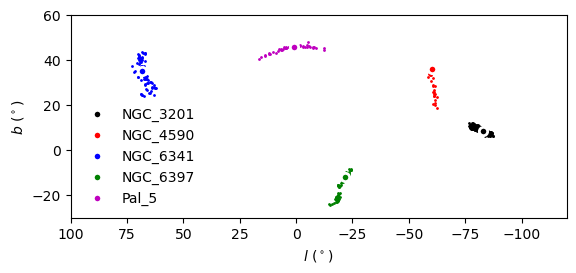

In [35]:
cs = ['k', 'r', 'b', 'g', 'm', 'orange']
for i in range(len(gc_stream_ids)):
    mask = d['stream_id'] == gc_stream_ids[i]
    plt.scatter(l[mask].wrap_at(180*u.deg), b[mask], c=cs[i], s=1)
    plt.scatter(l_wrap_at_180[idx_with_stream][i],data_mw['b'][idx_with_stream][i], fc=cs[i], ec='w', lw=2, label=gc_stream_list[i])

plt.xlabel(r'$l\ (^\circ)$')
plt.ylabel(r'$b\ (^\circ)$')
plt.xlim(100,-120)
plt.ylim(-30,60)
plt.legend(loc='lower left', frameon=False)
plt.gca().set_aspect(1)
plt.show()

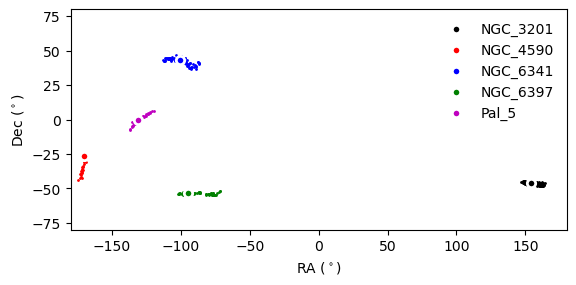

In [36]:
cs = ['k', 'r', 'b', 'g', 'm', 'orange']
for i in range(len(gc_stream_ids)):
    mask = d['stream_id'] == gc_stream_ids[i]
    x = np.copy(d['ra'])
    x[d['ra']>180] -= 360
    plt.scatter(x[mask], d['dec'][mask], c=cs[i], s=1)
    plt.scatter(ra_wrap_at_180[idx_with_stream][i],data_mw['DEC'][idx_with_stream][i], fc=cs[i], ec='w', lw=2, label=gc_stream_list[i])

plt.xlabel(r'RA $(^\circ)$')
plt.ylabel(r'Dec $(^\circ)$')
plt.xlim(-180,180)
plt.ylim(-80,80)
plt.legend(loc='upper right', frameon=False)
plt.gca().set_aspect(1)
plt.show()

### Fit streams with gala

In [37]:
pot = gp.BovyMWPotential2014(units=galactic)
pot = gp.MilkyWayPotential2022(units=galactic)
H = gp.Hamiltonian(pot)

In [ ]:
frame = 'ICRS'
t_tot = 2000 * u.Myr
dt = 1 * u.Myr

for i in range(len(gc_stream_ids)):
    print(gc_stream_list[i])
    mask = d['stream_id'] == gc_stream_ids[i]
    if frame == 'ICRS':
        x = np.copy(d['ra'])
        x[d['ra']>180] -= 360
        plt.scatter(x[mask], d['dec'][mask], c=cs[i], s=1)
    elif frame == 'Galactic':
        plt.scatter(l[mask].wrap_at(180*u.deg), b[mask], c=cs[i], s=1)

    c = coord.ICRS(ra=data_mw['RA'][idx_with_stream][i] * u.deg, dec=data_mw['DEC'][idx_with_stream][i] * u.deg,
        distance=data_mw['Rsun'][idx_with_stream][i] * u.kpc,
        pm_ra_cosdec=data_mw['mu_alpha'][idx_with_stream][i] * u.mas/u.yr,
        pm_dec=data_mw['mu_delta'][idx_with_stream][i] * u.mas/u.yr,
        radial_velocity=data_mw['<RV>'][idx_with_stream][i] * u.km/u.s)
    
    # c = coord.Galactocentric(
    #     x=-data_mw['X'][idx_with_stream][i] * u.kpc, 
    #     y=-data_mw['Y'][idx_with_stream][i] * u.kpc,
    #     z=data_mw['X'][idx_with_stream][i] * u.kpc,
    #     v_x=-data_mw['U'][idx_with_stream][i] * u.km/u.s,
    #     v_y=-data_mw['V'][idx_with_stream][i] * u.km/u.s,
    #     v_z=data_mw['W'][idx_with_stream][i] * u.km/u.s)
    
    c_gc = c.transform_to(coord.Galactocentric()).cartesian
    gc_w0 = gd.PhaseSpacePosition(c_gc)
    gc_mass = 10**mass_mw[np.where(name_mass_mw == gc_stream_list[i])[0][0]] * u.Msun
    print('GC mass = %.2e Msun, Rperi = %.2f kpc, Rapo = %.2f kpc'%(gc_mass.value, data_mw['RPERI'][idx_with_stream][i], data_mw['RAPO'][idx_with_stream][i]))
    gc_pot = gp.PlummerPotential(m=gc_mass, b=4*u.pc, units=galactic)

    df = ms.ChenStreamDF()
    gen = ms.MockStreamGenerator(df, pot, progenitor_potential=gc_pot)
    stream, _ = gen.run(gc_w0, gc_mass, dt=-dt, n_steps=int(t_tot/dt))
    
    if frame == 'ICRS':
        stream_c = stream.to_coord_frame(coord.ICRS())
        plt.scatter(stream_c.ra.wrap_at(180*u.deg), stream_c.dec, s=1, alpha=0.1, fc=cs[i])
        plt.scatter(ra_wrap_at_180[idx_with_stream][i],data_mw['DEC'][idx_with_stream][i], fc=cs[i], ec='w', lw=2, label=gc_stream_list[i])
    elif frame == 'Galactic':
        stream_c = stream.to_coord_frame(coord.Galactic())
        plt.scatter(stream_c.l.wrap_at(180*u.deg), stream_c.b, s=1, alpha=0.1, fc=cs[i])
        plt.scatter(l_wrap_at_180[idx_with_stream][i],data_mw['b'][idx_with_stream][i], fc=cs[i], ec='w', lw=2, label=gc_stream_list[i])
    
if frame == 'ICRS':
    plt.xlabel(r'RA $(^\circ)$')
    plt.ylabel(r'Dec $(^\circ)$')
    plt.xlim(-180,180)
    plt.ylim(-80,80)
elif frame == 'Galactic':
    plt.xlabel(r'$l\ (^\circ)$')
    plt.ylabel(r'$b\ (^\circ)$')
    plt.xlim(100,-120)
    plt.ylim(-30,60)

plt.legend(frameon=False)
plt.gca().set_aspect(1)
plt.show()

NGC_3201
GC mass = 1.41e+05 Msun, Rperi = 8.34 kpc, Rapo = 25.52 kpc
NGC_4590
GC mass = 1.32e+05 Msun, Rperi = 8.88 kpc, Rapo = 29.37 kpc
NGC_6341
GC mass = 3.12e+05 Msun, Rperi = 1.25 kpc, Rapo = 10.62 kpc
NGC_6397
GC mass = 8.98e+04 Msun, Rperi = 2.60 kpc, Rapo = 6.30 kpc
